# EstimIA — Analyse exploratoire des données (EDA)
**Région : Île-de-France (tous les départements : 75, 77, 78, 91, 92, 93, 94, 95)**

Ce notebook sert à :
1. Vérifier la qualité du dataset produit par `pipeline.py`
2. Visualiser la distribution des prix et des features
3. Préparer les slides de présentation

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

# Style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

# Charger le dataset propre
DATA_PATH = Path('../backend/data/processed/dataset_propre.csv')
df = pd.read_csv(
    DATA_PATH,
    parse_dates=['date_mutation'],
    dtype={'code_postal': str, 'code_insee': str, 'departement': str}
)
print(f'Dataset chargé : {len(df):,} transactions')
df.head()

Dataset chargé : 787,260 transactions


,id_mutation,date_mutation,annee,type_bien,prix,surface_m2,nb_pieces,prix_m2,latitude,longitude,code_insee,nom_commune,code_postal,score_dpe_median,score_georisques,score_delinquance,departement
0,2021-1682562,2021-01-05,2021,Appartement,1480000.0,111.0,5.0,13333.33,48.876954,2.320982,75108,Paris 8e Arrondissement,75008,5.0,2.5,2.3,75
1,2021-1682564,2021-01-08,2021,Appartement,410000.0,31.0,2.0,13225.81,48.862768,2.349422,75101,Paris 1er Arrondissement,75001,5.0,2.5,2.3,75
2,2021-1682567,2021-01-07,2021,Appartement,300000.0,23.0,1.0,13043.48,48.856147,2.367136,75103,Paris 3e Arrondissement,75003,5.0,2.5,2.3,75
3,2021-1682569,2021-01-06,2021,Appartement,1000000.0,60.0,2.0,16666.67,48.859331,2.362974,75103,Paris 3e Arrondissement,75003,5.0,2.5,2.3,75
4,2021-1682571,2021-01-08,2021,Appartement,1525559.0,91.0,4.0,16764.38,48.866139,2.306396,75108,Paris 8e Arrondissement,75008,5.0,2.5,2.3,75


## 1. Vue d'ensemble du dataset

In [89]:
# Statistiques descriptives principales
print('=== Statistiques générales ===')
print(f"Période : {df['annee'].min():.0f} – {df['annee'].max():.0f}")
print(f"Transactions : {len(df):,}")
print(f"Appartements : {(df['type_bien']=='Appartement').sum():,}")
print(f"Maisons      : {(df['type_bien']=='Maison').sum():,}")
print()

desc = df[['prix', 'surface_m2', 'prix_m2', 'nb_pieces', 'score_georisques','score_delinquance']].describe().round(1)
display(desc)

=== Statistiques générales ===
Période : 2021 – 2025
Transactions : 787,260
Appartements : 540,075
Maisons      : 247,185



,prix,surface_m2,prix_m2,nb_pieces,score_georisques,score_delinquance
count,787260.0,787260.0,787260.0,787260.0,787260.0,787260.0
mean,435315.4,71.0,6905.8,3.2,4.4,1.3
std,487129.4,43.1,6106.5,1.6,2.8,0.5
min,10000.0,5.0,500.0,0.0,0.0,0.9
25%,200000.0,41.0,3306.5,2.0,2.5,1.0
50%,307000.0,64.0,4950.0,3.0,3.8,1.2
75%,485000.0,89.0,8718.0,4.0,6.2,1.5
max,19346000.0,880.0,50000.0,80.0,10.0,2.3


In [90]:
# Valeurs manquantes
missing = df.isna().sum()
missing = missing[missing > 0]
if missing.empty:
    print('Aucune valeur manquante - dataset propre.')
else:
    print('Valeurs manquantes :')
    print(missing)

Valeurs manquantes :
code_postal              4
score_dpe_median    622963
dtype: int64


## 2. Distribution des prix

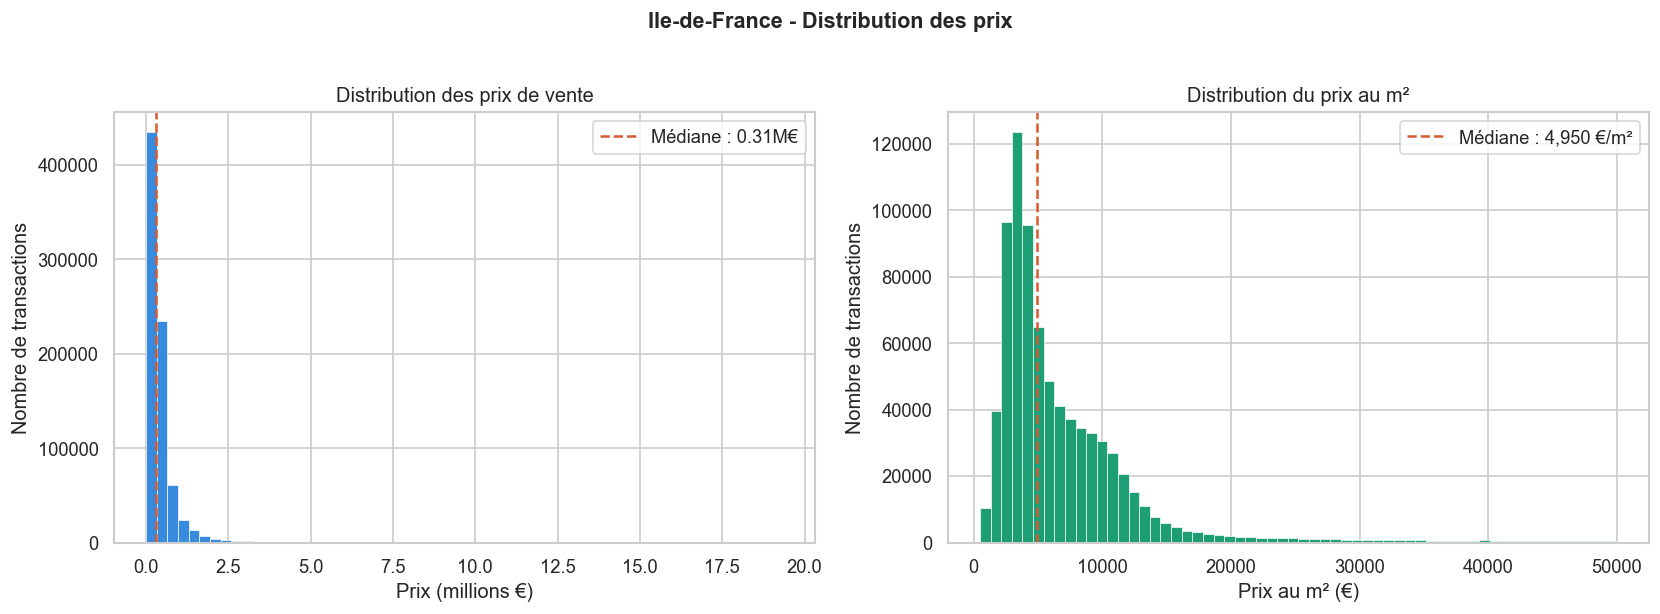

In [91]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution prix total
axes[0].hist(df['prix'] / 1e6, bins=60, color='#378ADD', edgecolor='white', linewidth=0.4)
axes[0].set_title('Distribution des prix de vente')
axes[0].set_xlabel('Prix (millions €)')
axes[0].set_ylabel('Nombre de transactions')
median_prix = df['prix'].median() / 1e6
axes[0].axvline(median_prix, color='#D85A30', linestyle='--', linewidth=1.5, label=f'Médiane : {median_prix:.2f}M€')
axes[0].legend()

# Distribution prix au m²
axes[1].hist(df['prix_m2'], bins=60, color='#1D9E75', edgecolor='white', linewidth=0.4)
axes[1].set_title('Distribution du prix au m²')
axes[1].set_xlabel('Prix au m² (€)')
axes[1].set_ylabel('Nombre de transactions')
median_m2 = df['prix_m2'].median()
axes[1].axvline(median_m2, color='#D85A30', linestyle='--', linewidth=1.5, label=f'Médiane : {median_m2:,.0f} €/m²')
axes[1].legend()

plt.suptitle('Ile-de-France - Distribution des prix', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../docs/fig_distribution_prix.png', bbox_inches='tight', dpi=150)
plt.show()

## 3. Analyse géographique des prix (Départements et Codes Postaux)

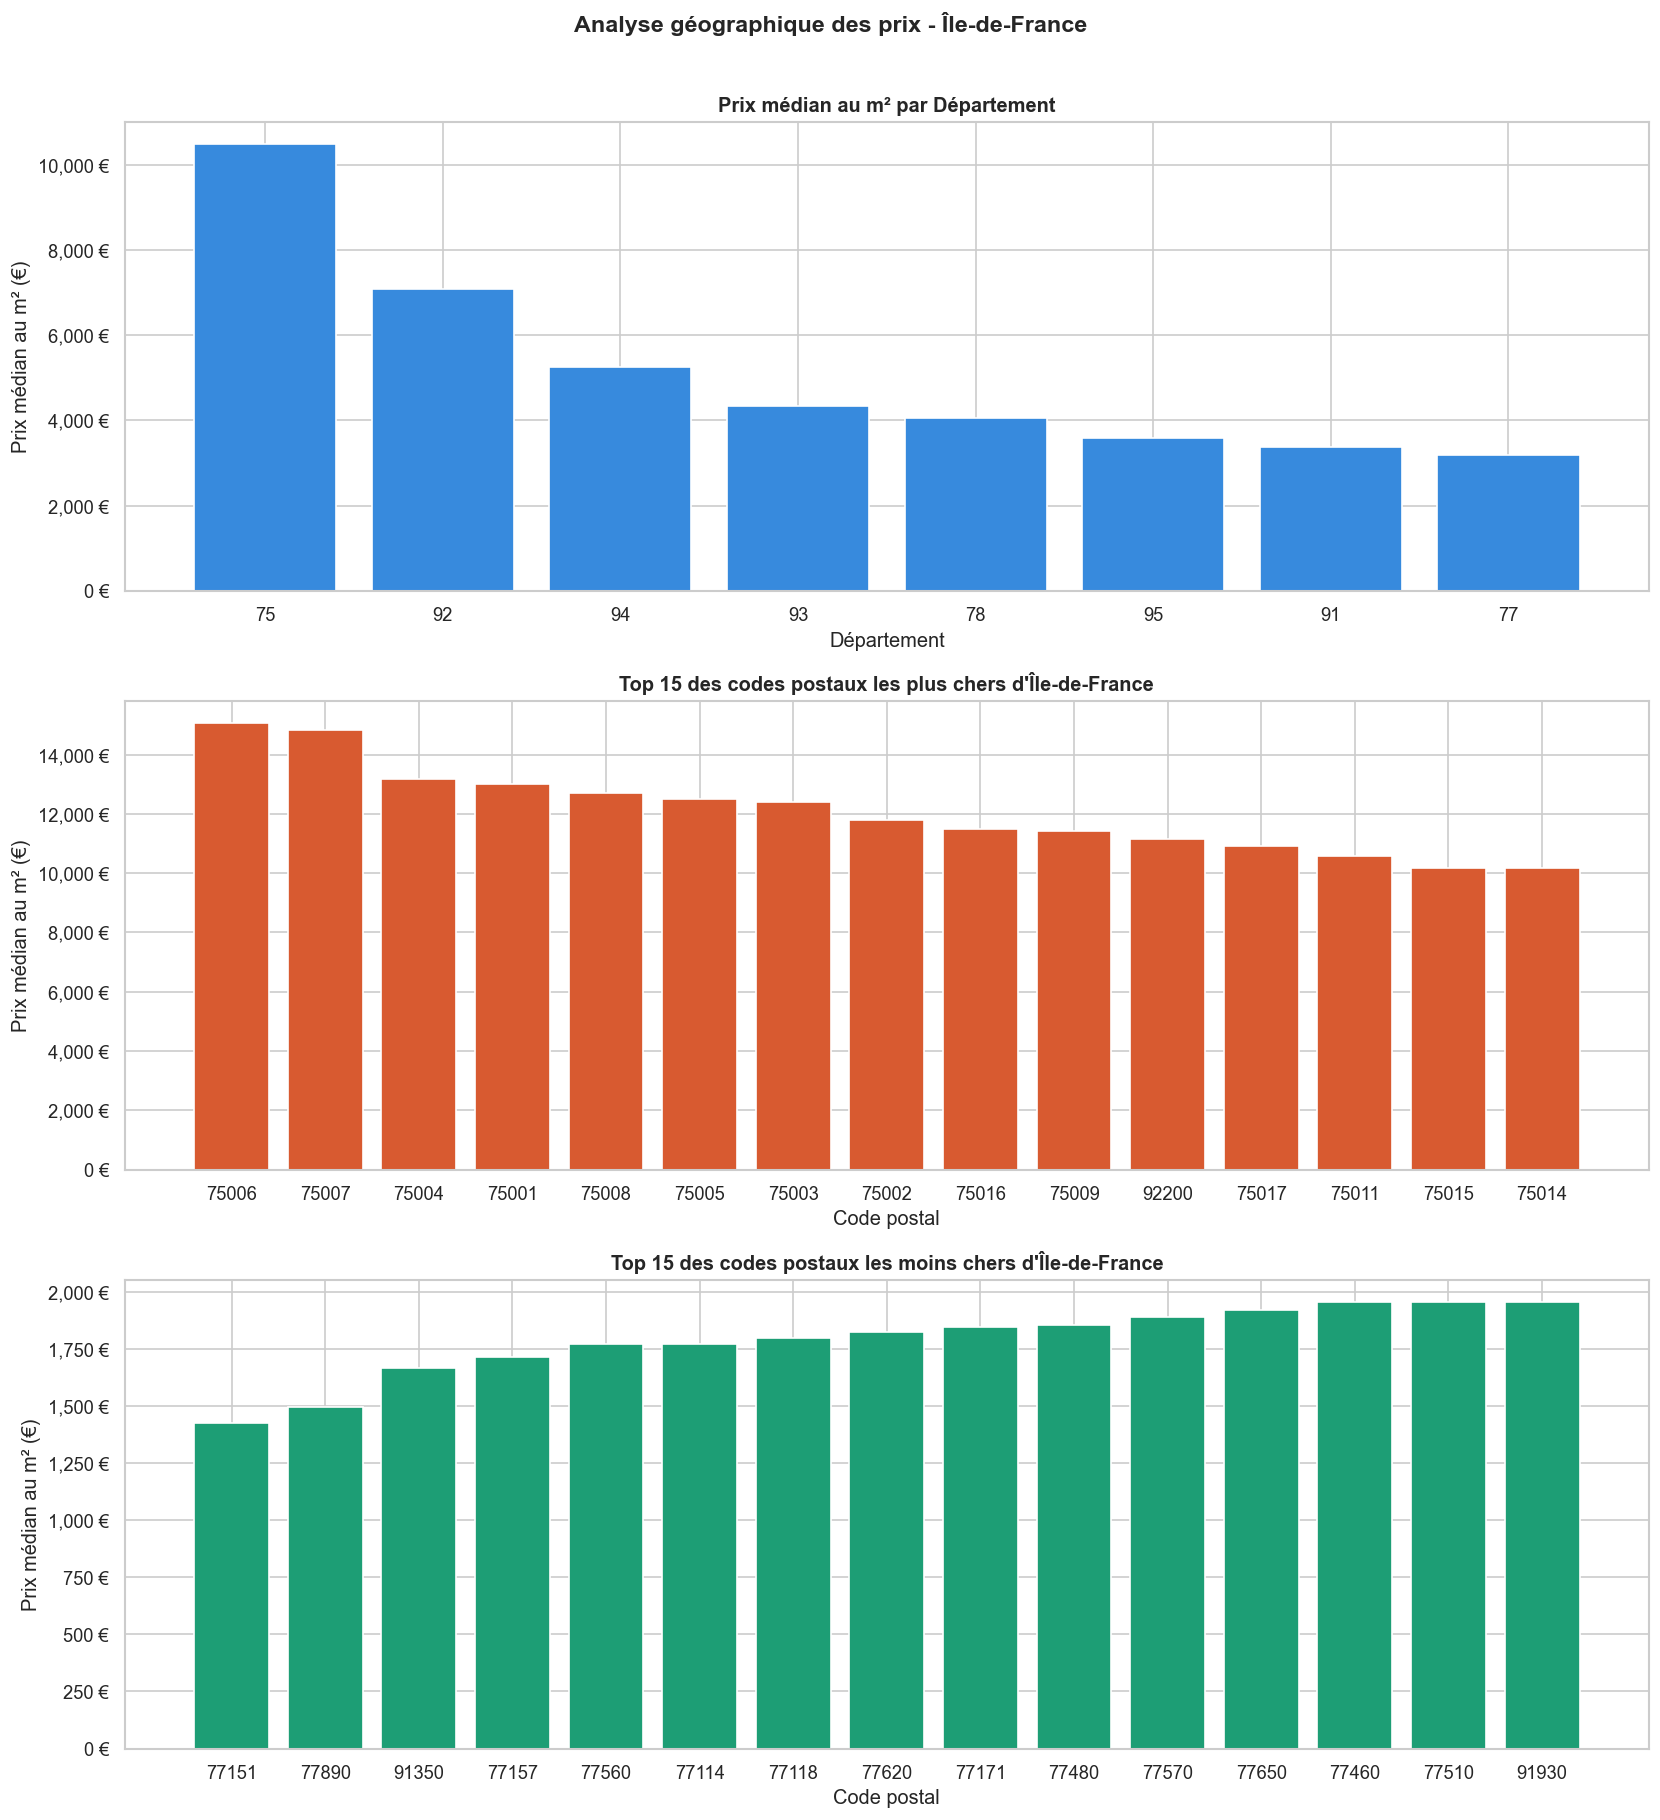

In [92]:
prix_dept = (
    df.groupby('departement')['prix_m2']
    .median()
    .reset_index()
    .sort_values('prix_m2', ascending=False)
)

top_15 = (
    df.groupby('code_postal')['prix_m2']
    .median()
    .reset_index()
    .sort_values('prix_m2', ascending=False)
    .head(15)
)

bottom_15 = (
    df.groupby('code_postal')['prix_m2']
    .median()
    .reset_index()
    .sort_values('prix_m2', ascending=True)
    .head(15)
)

fig, axes = plt.subplots(3, 1, figsize=(14, 15))

# 1. Prix médian par département
axes[0].bar(prix_dept['departement'].astype(str), prix_dept['prix_m2'], color='#378ADD', edgecolor='white')
axes[0].set_title('Prix médian au m² par Département', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Département')
axes[0].set_ylabel('Prix médian au m² (€)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f} €'))

# 2. Top 15 des codes postaux les plus chers
axes[1].bar(top_15['code_postal'].astype(str), top_15['prix_m2'], color='#D85A30', edgecolor='white')
axes[1].set_title("Top 15 des codes postaux les plus chers d'Île-de-France", fontsize=12, fontweight='bold')
axes[1].set_xlabel('Code postal')
axes[1].set_ylabel('Prix médian au m² (€)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f} €'))

# 3. Top 15 des codes postaux les moins chers (Flop 15)
axes[2].bar(bottom_15['code_postal'].astype(str), bottom_15['prix_m2'], color='#1D9E75', edgecolor='white')
axes[2].set_title("Top 15 des codes postaux les moins chers d'Île-de-France", fontsize=12, fontweight='bold')
axes[2].set_xlabel('Code postal')
axes[2].set_ylabel('Prix médian au m² (€)')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f} €'))

plt.suptitle('Analyse géographique des prix - Île-de-France', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../docs/fig_prix_code_postal.png', bbox_inches='tight', dpi=150)
plt.show()

## 4. Carte de chaleur des transactions (Plotly)

In [93]:
# Carte interactive des prix au m² géolocalisés
# Échantillon pour la lisibilité (max 5000 points)
sample = df.sample(min(5000, len(df)), random_state=42)

fig = px.scatter_mapbox(
    sample,
    lat='latitude',
    lon='longitude',
    color='prix_m2',
    size='surface_m2',
    color_continuous_scale='RdYlGn_r',
    range_color=[sample['prix_m2'].quantile(0.05), sample['prix_m2'].quantile(0.95)],
    hover_data={
        'prix': ':,.0f',
        'prix_m2': ':,.0f',
        'surface_m2': ':.0f',
        'type_bien': True,
        'nb_pieces': True,
    },
    mapbox_style='carto-positron',
    zoom=9,
    center={'lat': 48.8566, 'lon': 2.3522},
    title='Prix au m² — Île-de-France (75, 77, 78, 91, 92, 93, 94, 95)',
    labels={'prix_m2': 'Prix/m² (€)'},
    height=550,
)
fig.update_layout(margin=dict(l=0, r=0, t=40, b=0))
fig.write_html('../docs/carte_prix_idf.html')
fig.show()

## 5. Corrélations features → prix

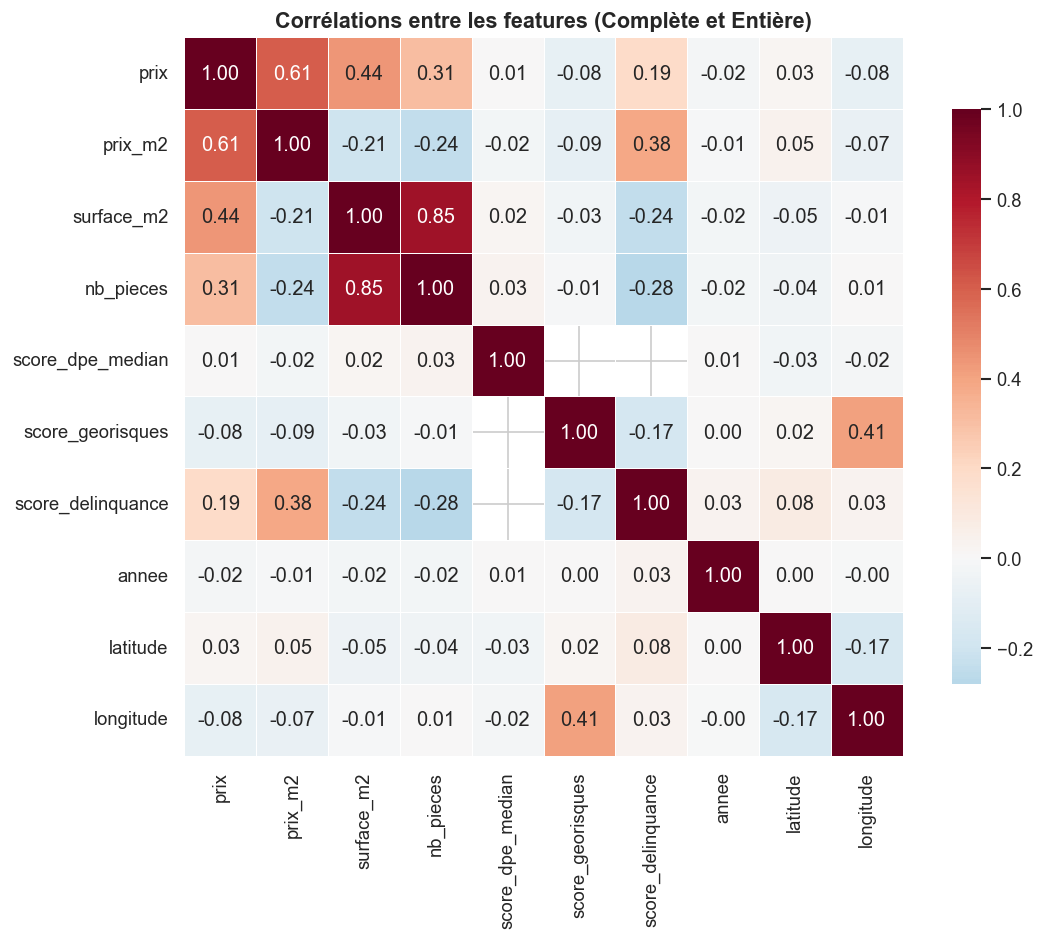

In [94]:
# Matrice de corrélation (Entière et Complète)
num_cols = ['prix', 'prix_m2', 'surface_m2', 'nb_pieces', 'score_dpe_median', 'score_georisques', 'score_delinquance', 'annee', 'latitude', 'longitude']
num_cols = [c for c in num_cols if c in df.columns]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    ax=ax,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8},
)
ax.set_title('Corrélations entre les features (Complète et Entière)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../docs/fig_correlations.png', bbox_inches='tight', dpi=150)
plt.show()


## 6. Évolution des prix dans le temps

In [95]:
prix_temps = (
    df.groupby(['annee', 'type_bien'])['prix_m2']
    .median()
    .reset_index()
)

fig = px.line(
    prix_temps,
    x='annee',
    y='prix_m2',
    color='type_bien',
    markers=True,
    title='Évolution du prix médian au m² — Île-de-France',
    labels={'prix_m2': 'Prix médian au m² (€)', 'annee': 'Année', 'type_bien': 'Type'},
    color_discrete_map={'Appartement': '#378ADD', 'Maison': '#D85A30'},
)
fig.update_layout(yaxis_tickformat=',.0f')
fig.write_html('../docs/fig_evolution_prix.html')
fig.show()

## 7. Analyse des risques environnementaux et de la délinquance par Département

Puisque le taux de délinquance est une statistique fournie à l'échelle départementale et que les risques environnementaux (Géorisques) présentent des tendances macro-géographiques fortes tout en variant au niveau local, nous étudions ces deux dimensions agrégées par département en Île-de-France. Nous utilisons un graphique à barres pour la délinquance moyenne et un boxplot (boîte à moustaches) pour le score de Géorisques afin de révéler à la fois la variabilité intra-départementale (les communes) et inter-départementale.

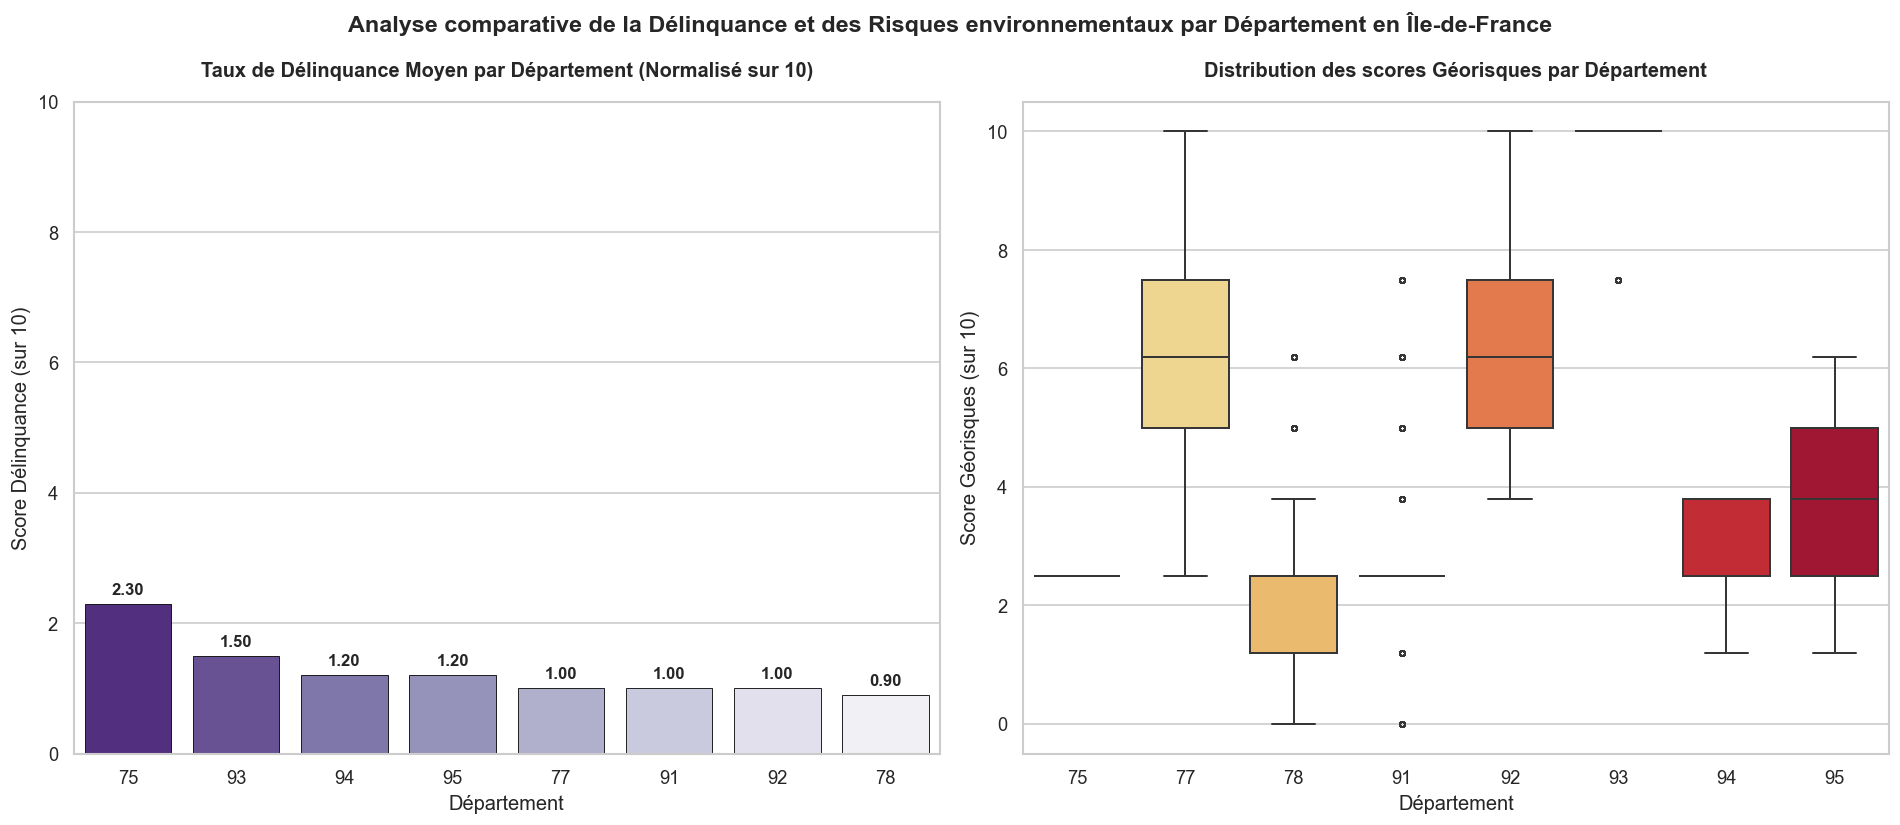

In [96]:
# Analyse comparative de la Délinquance et des Risques environnementaux par Département
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# S'assurer que le département est trié et au format chaîne
df['departement_str'] = df['departement'].astype(str).str.zfill(2)

# Agréger le taux de délinquance par département (score constant par département)
del_agg = df.groupby('departement_str')['score_delinquance'].mean().reset_index().sort_values('score_delinquance', ascending=False)

# 1. Taux de délinquance par département (Barplot)
sns.barplot(
    x='departement_str',
    y='score_delinquance',
    data=del_agg,
    ax=axes[0],
    palette='Purples_r',
    hue='departement_str',
    legend=False,
    edgecolor='black',
    linewidth=0.5
)
axes[0].set_title('Taux de Délinquance Moyen par Département (Normalisé sur 10)', fontsize=12, fontweight='bold', pad=15)
axes[0].set_xlabel('Département')
axes[0].set_ylabel('Score Délinquance (sur 10)')
axes[0].set_ylim(0, 10)

# Ajouter les valeurs textuelles sur les barres
for p in axes[0].patches:
    height = p.get_height()
    axes[0].annotate(f'{height:.2f}',
                (p.get_x() + p.get_width() / 2., height + 0.1),
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Distribution des risques environnementaux par département (Boxplot)
sns.boxplot(
    x='departement_str',
    y='score_georisques',
    data=df.sort_values('departement_str'),
    ax=axes[1],
    palette='YlOrRd',
    hue='departement_str',
    legend=False,
    linewidth=1.2,
    fliersize=3
)
axes[1].set_title('Distribution des scores Géorisques par Département', fontsize=12, fontweight='bold', pad=15)
axes[1].set_xlabel('Département')
axes[1].set_ylabel('Score Géorisques (sur 10)')
axes[1].set_ylim(-0.5, 10.5)

plt.suptitle('Analyse comparative de la Délinquance et des Risques environnementaux par Département en Île-de-France', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('../docs/fig_risques_delinquance_departement.png', bbox_inches='tight', dpi=150)
plt.show()


## 8. Résumé — Ce que le dataset permet de prédire

Le dataset `dataset_propre.csv` contient :
- Les **features d'entrée** pour le modèle ML : surface, nb pièces, localisation GPS, DPE, géorisques, délinquance
- La **variable cible** : `prix` (et `prix_m2`)

**Prochaine étape** : `02_regression_experiments.ipynb` — entraînement du modèle Random Forest.